# Battery Storage Dispatch Optimization for Energy Arbitrage and Peak Shaving

## Executive Summary

A grid-connected commercial site operates a 2 MW / 8 MWh lithium-ion battery alongside a metered electrical load. The site is billed two ways: an hourly day-ahead **energy price** ($/MWh) and a monthly **demand charge** on its single highest grid-import interval ($/MW). The asset manager must decide, hour by hour, when to charge the battery (buying cheap energy and raising grid draw) and when to discharge it (offsetting expensive energy and lowering grid draw). Two value streams compete: **energy arbitrage** (buy low overnight, discharge at the evening peak) and **peak shaving** (cap the billed grid maximum). Charging is not free — round-trip efficiency means roughly 10% of stored energy is lost — so the schedule is a genuine optimization, not a heuristic.

This notebook builds the decision end-to-end. It first synthesizes a realistic 24-hour day-ahead price curve (with morning and evening peaks plus an overnight trough) and a correlated site load profile, then profiles both with **PROC MEANS** and a robust **PROC UNIVARIATE** 2.5/97.5 percentile price band. The core is a linear program in **PROC OPTMODEL**: decision variables for hourly charge, discharge, and state of charge, plus a billed-peak variable, subject to a cumulative state-of-charge balance (with separate charge/discharge efficiency), power and capacity limits, and a peak-definition constraint. The objective maximizes arbitrage margin net of the demand charge. **PROC SQL** then quantifies baseline-versus-optimized cost, and three **PROC SGPLOT** panels visualize the charge/discharge schedule against price, the state-of-charge trajectory, and the flattened grid-import profile.

**Result on the synthetic day:** the optimizer fills the battery during the cheapest overnight hours, discharges into both the morning and evening price peaks, recharges through the mid-day price valley, and — crucially — holds its charging power back so it never creates a new grid peak. Daily energy cost falls from **\$2,903.78 to \$2,528.43** — **\$375.34 (12.9%) of arbitrage savings** — while the billed grid maximum drops from **3.59 MW to 3.43 MW** (about **0.16 MW**), worth a further **\$18.98** at the assumed daily-share demand charge. The same model scales to longer horizons, multiple price scenarios, or degradation-aware cycling simply by extending the index set and constraints.

## Data Sources

All data is **synthetic**, generated inline in the first code cell with `CALL STREAMINIT(20260605)` for reproducibility. No external files or network access. One dataset, `price_load`, with 24 hourly rows representing a single operating day.

| Variable | Type | Units | Description |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Hour of the operating day (horizon index) |
| `price` | num | $/MWh | Day-ahead energy price: overnight trough, morning + evening peaks, with Gaussian noise (floored at $5) |
| `load` | num | MW | Site electrical demand, correlated with daily activity (floored at 0.3 MW) |
| `day_type` | char | — | Tariff window flag: `PeakTOU` (hours 17–21) vs `OffPeak`, used for the peak/off-peak price spread summary |

Battery parameters are fixed model constants inside PROC OPTMODEL: 8 MWh usable capacity, 2 MW max charge/discharge power, 0.95 charge and 0.95 discharge efficiency (~90% round trip), starting state of charge 0 MWh, and a \$120/MW demand charge applied to the day's billed grid peak (the daily-amortized share of a monthly demand charge).

# Battery Storage Dispatch Optimization
## Energy arbitrage and peak shaving for a grid-connected site

A commercial site runs a **2 MW / 8 MWh battery** behind its meter. Its electricity bill has two parts: an hourly **energy price** ($/MWh) and a monthly **demand charge** on the single highest grid-import interval ($/MW). The operator wants an hourly charge/discharge schedule that captures two value streams at once:

- **Arbitrage** — store cheap overnight energy, release it during expensive peak hours.
- **Peak shaving** — discharge during the demand spike to lower the billed grid maximum.

Because round-trip efficiency loses ~10% of stored energy, the trade-off is non-trivial and warrants a true optimization. We formulate it as a linear program in **PROC OPTMODEL**, then quantify and visualize the result.

> All data below is synthetic and generated inline — the notebook is fully self-contained and runs in a few seconds.

## 1. Generate a synthetic day-ahead price and load profile

We build one operating day (24 hourly rows). The price curve has an overnight trough and morning + evening peaks; site load is correlated with daily activity. A fixed seed keeps the run reproducible. We also tag the statutory time-of-use peak window so we can summarize the peak/off-peak spread later.

In [1]:
data price_load;
    call streaminit(20260605);
    length day_type $7;
    do hour = 0 to 23;
        /* Diurnal energy price ($/MWh): morning + evening peaks */
        base = 38
             + 26 * exp(-((hour - 8)**2) / 6)
             + 40 * exp(-((hour - 19)**2) / 5)
             - 14 * exp(-((hour - 3)**2) / 8);
        price = round(base + rand('normal', 0, 4), 0.01);
        if price < 5 then price = 5;

        /* Site load (MW): overnight trough, evening ramp */
        load = round(2.0
             + 1.6 * exp(-((hour - 19)**2) / 7)
             + 0.7 * exp(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        if load < 0.3 then load = 0.3;

        if hour >= 17 and hour <= 21 then day_type = 'PeakTOU';
        else day_type = 'OffPeak';
        output;
    end;
    drop base;
run;

NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profile the price and load distributions

Before optimizing, we sanity-check the inputs. The spread between the cheapest and most expensive hours is what arbitrage monetizes, and the maximum load anchors the peak-shaving opportunity.

In [2]:
proc means data=price_load n mean std min max maxdec=2;
    var price load;
run;

                                                  The MEANS Procedure

 Variable        N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------
 price          24       46.29       15.81       18.57       79.27
 load           24        2.47        0.48        1.71        3.59
 -----------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Peak vs off-peak price spread

Grouping by the time-of-use flag shows how much richer the on-peak hours are than the off-peak baseline — the structural signal the battery exploits.

In [3]:
proc means data=price_load mean min max maxdec=2;
    class day_type;
    var price;
run;

                                                  The MEANS Procedure

                                               Analysis Variable : price

                              N
        day_type            Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        OffPeak              19          40.46          18.57          54.89
        PeakTOU               5          68.45          54.88          79.27
        --------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robust price band (2.5 / 97.5 percentiles)

We characterize the price tails with a 2.5 / 97.5 percentile band. **PROC UNIVARIATE** with `PCTLPTS=` computes arbitrary percentiles cleanly, which is the correct tool for fractional percentiles.

In [4]:
proc univariate data=price_load noprint;
    var price;
    output out=price_band pctlpts=2.5 97.5 pctlpre=p_;
run;

proc print data=price_band noobs;
run;


P_2_5  P_97_5
-----  ------
18.57   79.27



NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. The dispatch optimization (linear program)

We read the hourly price and load into PROC OPTMODEL and declare:

- `chg[h]`, `dis[h]` — hourly charge / discharge power (MW), bounded by the 2 MW inverter rating.
- `soc[h]` — state of charge (MWh), bounded by the 8 MWh usable capacity.
- `peak` — the billed grid maximum (MW).

**Constraints.** `soc_balance` accumulates net energy through each hour with separate charge/discharge efficiency (a running-sum form of the hourly recurrence). `peak_def` forces `peak` to dominate every hour's net grid import, so minimizing it shaves the demand charge.

**Objective.** Maximize arbitrage margin — `price × (discharge − charge)` summed over the day — minus the demand charge on the billed peak. We solve as a continuous LP.

In [5]:
proc optmodel;
    set HOURS;
    num price{HOURS};
    num load{HOURS};

    read data price_load into HOURS=[hour]
        price=price col=price
        load=load col=load;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    var chg{HOURS}  >= 0 <= p_max;
    var dis{HOURS}  >= 0 <= p_max;
    var soc{HOURS}  >= 0 <= capacity;
    var peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h in HOURS} = load[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h in HOURS}:
        soc[h] = soc0
                 + sum{k in HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h in HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    max net_value =
        sum{h in HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve with lp;

    create data dispatch from [hour=HOURS]
        price=price[hour]
        load=load[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526



NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.17.1
NOTE: PROC OPTMODEL completed.


## 6. The optimal hourly schedule

The solved table shows charge spread across the cheap overnight and mid-day hours — moderated to roughly 1.0–1.7 MW so it never sets a new grid peak — discharge concentrated in the morning and evening price peaks, and the state of charge tracing a sensible fill-and-release cycle within the 8 MWh cap. The `grid_mw` column holds a flat ~3.43 MW ceiling through every charging hour, the signature of the binding peak constraint.

In [6]:
proc print data=dispatch noobs;
    var hour price load charge_mw discharge_mw soc_mwh grid_mw;
run;


HOUR  PRICE  LOAD   CHARGE_MW  DISCHARGE_MW    SOC_MWH     GRID_MW
----  -----  ----  ----------  ------------  ---------  ----------
   0  29.73  1.99   1.4418421             0    1.36975   3.4318421
   1  28.03  2.16   1.2718421             0      2.578   3.4318421
   2  21.87     2   1.4318421             0    3.93825   3.4318421
   3  18.57  1.71   1.7218421             0      5.574   3.4318421
   4  27.62  2.13   1.3018421             0    6.81075   3.4318421
   5  36.12  2.18   1.2518421             0          8   3.4318421
   6  50.37  2.32           0             0          8        2.32
   7  54.56  2.47           0             2  5.8947368        0.47
   8  54.89  2.88           0             2  3.7894737        0.88
   9   53.4  2.78           0             2  1.6842105        0.78
  10  50.51  2.72           0             0  1.6842105        2.72
  11  47.58  2.41  0.50898892             0    2.16775  2.91898892
  12  41.79  2.21   1.2218421             0     3.3285   3.43

NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Headline KPIs: baseline vs optimized

We compare the do-nothing baseline (pay the price for the raw load every hour) against the optimized grid position, and report the arbitrage savings, the reduction in billed peak, and the dollar value of that reduction at the demand charge — the two levers that drive the business case.

In [7]:
proc sql;
    create table kpi as
    select
        sum(price * load)                        as base_energy_cost,
        sum(price * grid_mw)                     as opt_energy_cost,
        sum(price * load) - sum(price * grid_mw) as arbitrage_savings,
        max(load)                                as base_peak_mw,
        max(grid_mw)                             as opt_peak_mw,
        max(load) - max(grid_mw)                 as peak_reduction_mw,
        120 * (max(load) - max(grid_mw))         as demand_charge_savings
    from dispatch;
quit;

proc print data=kpi noobs;
run;

BASE_ENERGY_COST  OPT_ENERGY_COST  ARBITRAGE_SAVINGS  BASE_PEAK_MW  OPT_PEAK_MW  PEAK_REDUCTION_MW  DEMAND_CHARGE_SAVINGS
----------------  ---------------  -----------------  ------------  -----------  -----------------  ---------------------
       2903.7774  2528.4335145526     375.3438854474          3.59    3.4318421          0.1581579              18.978948



NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Charge / discharge schedule against price

Charge (blue needles) and discharge (red line with markers) share the left megawatt axis; the day-ahead price (green dashed) is read on the right. Charging clusters in the cheap overnight and mid-day hours, while discharge fires into the morning and evening price peaks — the visual confirms the optimizer is buying low and selling high.

NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


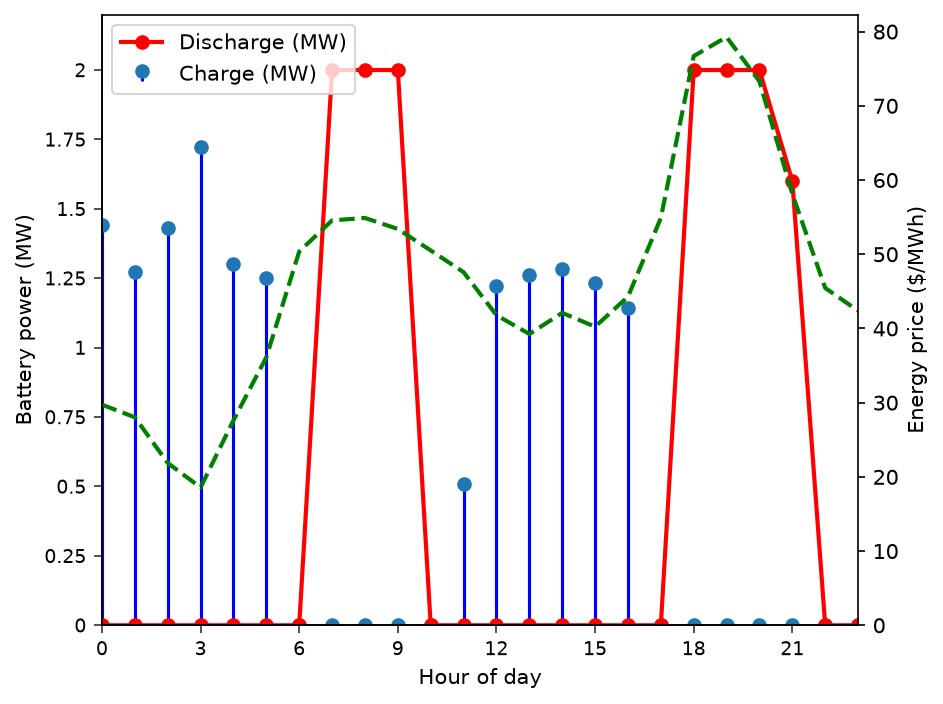

In [8]:
proc sgplot data=dispatch;
    needle x=hour y=charge_mw / lineattrs=(color=blue thickness=3)
        legendlabel="Charge (MW)";
    series x=hour y=discharge_mw / lineattrs=(color=red thickness=2)
        markers legendlabel="Discharge (MW)";
    series x=hour y=price / y2axis lineattrs=(color=green pattern=dash thickness=2)
        legendlabel="Price ($/MWh)";
    xaxis label="Hour of day" values=(0 to 23 by 3);
    yaxis label="Battery power (MW)" min=0 max=2.2;
    y2axis label="Energy price ($/MWh)" min=0;
run;

## 9. State-of-charge trajectory

The stored energy rises as the battery fills overnight, draws down through each discharge window, and never breaches the 8 MWh usable-capacity ceiling (dotted reference).

NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


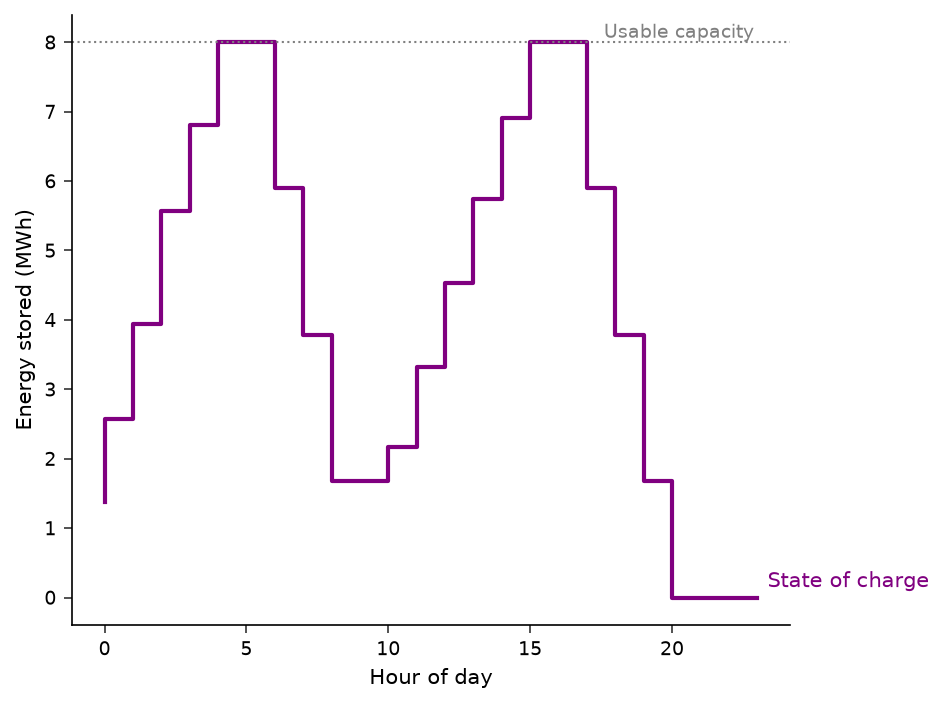

In [9]:
proc sgplot data=dispatch;
    step x=hour y=soc_mwh / lineattrs=(color=purple thickness=2)
        curvelabel="State of charge";
    refline 8 / axis=y lineattrs=(color=grey pattern=dot)
        label="Usable capacity";
    xaxis label="Hour of day";
    yaxis label="Energy stored (MWh)";
run;

## 10. Grid import: before vs after dispatch

The orange line (grid import with the battery) drops well below the dashed baseline load through the evening ramp (hours 18–21) — the peak-shaving effect that lowers the demand charge. During the overnight and mid-day charging windows it rises, but the optimizer caps it at a flat ~3.43 MW ceiling that stays *under* the original 3.59 MW load peak, so charging buys cheap energy without setting a new billed maximum.

NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


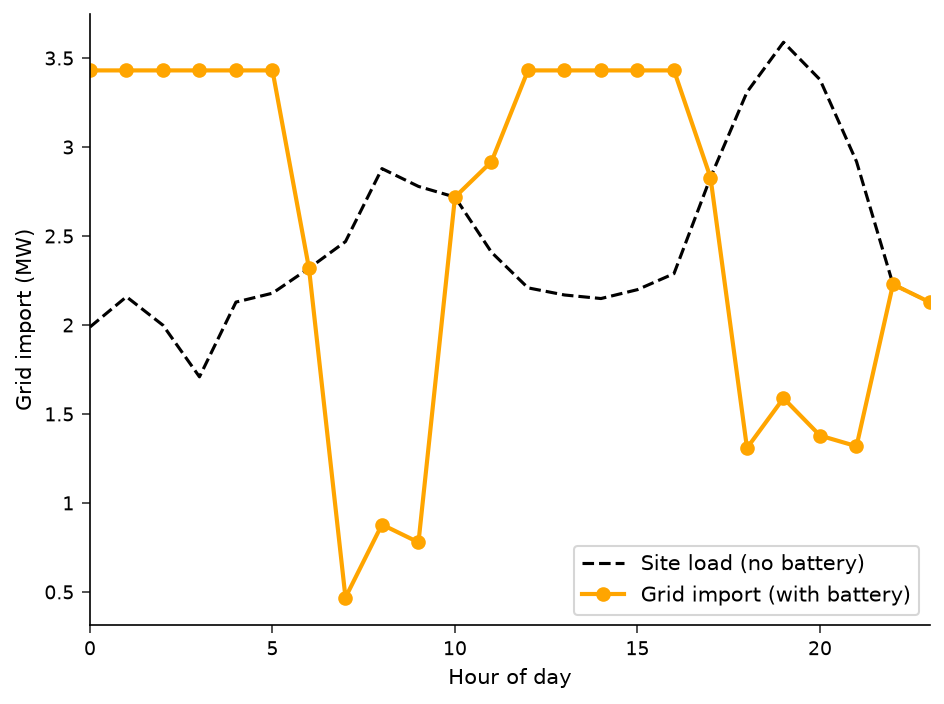

In [10]:
proc sgplot data=dispatch;
    series x=hour y=load / lineattrs=(color=black pattern=dash)
        legendlabel="Site load (no battery)";
    series x=hour y=grid_mw / lineattrs=(color=orange thickness=2)
        markers legendlabel="Grid import (with battery)";
    xaxis label="Hour of day";
    yaxis label="Grid import (MW)";
run;

## Interpretation and next steps

**What the model decided.** With round-trip efficiency taxing every cycle, the optimizer still found clear value: it filled the battery during the cheapest overnight hours, discharged into the morning price peak (hours 7–9), recharged through the mid-day price valley (hours 11–16), and discharged again into the richest evening peak (hours 18–21). Tellingly, it charged at only 1.0–1.7 MW rather than the full 2 MW rating during the overnight fill — holding power back so the added grid draw never pushed import above the day's load peak. The state of charge respected both the 8 MWh capacity and the 2 MW power limit at all times.

**The business case.** Daily energy cost fell from **\$2,903.78 to \$2,528.43** — **\$375.34 (12.9%)** of arbitrage savings — and the billed grid maximum dropped from **3.59 MW to 3.43 MW** (about **0.16 MW**), trimming a further **\$18.98** off the demand-charge line. Annualized across operating days plus the recurring demand-charge reduction, this is the kind of margin that underwrites a storage investment.

**Why an LP is the right tool.** Heuristics ("charge below the median price, discharge above") ignore efficiency losses, capacity coupling across hours, and the fact that the demand charge depends on a single interval — they would charge at full power overnight and *raise* the billed peak, destroying the peak-shaving value. PROC OPTMODEL captures all of these in one declarative model and returns the provably optimal schedule, which here deliberately moderates the charging rate to protect the peak.

**Extending the model.**

- **Longer horizons / multi-day** — widen the `HOURS` index set; add inter-day cycling limits.
- **Price uncertainty** — solve the LP across multiple price scenarios and average the first-hour decision (a rolling stochastic policy).
- **Battery degradation** — add a throughput penalty term or a constraint on cumulative cycles to trade arbitrage against asset life.
- **Frequency response / capacity markets** — introduce reserved-headroom constraints so the battery can stack ancillary-service revenue on top of arbitrage.

All of these are incremental edits to the same OPTMODEL block — the structure established here carries through unchanged.